In [ ]:
!pip install -q transformers==4.46.3 sentence-transformers==5.1.0 accelerate datasets evaluate rouge-score bert-score sacrebleu sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 483.4/483.4 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 63.8 MB/s eta 0:00:00


In [ ]:
import transformers
import sentence_transformers

print(transformers.__version__)
print(sentence_transformers.__version__)

4.46.3
5.1.0


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving validation.csv to validation.csv
Saving train.csv to train.csv
Saving test.csv to test.csv


In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import os
import gc
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import evaluate

from tqdm import tqdm
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import (
    MT5Tokenizer,
    MT5ForConditionalGeneration,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    EarlyStoppingCallback
)
from rouge_score import rouge_scorer
from bert_score import score as bertscore

In [ ]:
# ============================================================
# LOAD DATA
# CHANGE PATH AS NEEDED
# ============================================================

TRAIN_PATH = "/content/train.csv"
VAL_PATH   = "/content/validation.csv"
TEST_PATH  = "/content/test.csv"

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(7758, 3)
(970, 3)
(970, 3)


In [ ]:
# ============================================================
# BASIC CLEANING
# ============================================================

for df in [train_df, val_df, test_df]:
    df.dropna(subset=["article", "summary"], inplace=True)
    df["article"] = df["article"].astype(str)
    df["summary"] = df["summary"].astype(str)

print(train_df.shape, val_df.shape, test_df.shape)

(7758, 3) (970, 3) (970, 3)


In [ ]:
# ============================================================
# CONVERT TO HF DATASETS
# ============================================================

train_dataset = Dataset.from_pandas(train_df)
val_dataset   = Dataset.from_pandas(val_df)
test_dataset  = Dataset.from_pandas(test_df)

In [ ]:
# ============================================================
# LOAD MODEL
# ============================================================

MODEL_NAME = "google/mt5-base"

tokenizer = MT5Tokenizer.from_pretrained(MODEL_NAME)

model = MT5ForConditionalGeneration.from_pretrained(MODEL_NAME)

model.gradient_checkpointing_enable()
model.config.use_cache = False

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


pytorch_model.bin:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
# ============================================================
# TOKENIZATION SETTINGS
# ============================================================

MAX_INPUT = 128
MAX_TARGET = 48

In [ ]:
# ============================================================
# PREPROCESS FUNCTION
# ============================================================

def preprocess(examples):

    inputs = [
        "summarize: " + text
        for text in examples["article"]
    ]

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT,
        truncation=True,
        padding="max_length"
    )

    labels = tokenizer(
        text_target=examples["summary"],
        max_length=MAX_TARGET,
        truncation=True,
        padding="max_length"
    )

    labels["input_ids"] = [
        [
            token if token != tokenizer.pad_token_id else -100
            for token in seq
        ]
        for seq in labels["input_ids"]
    ]

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

In [ ]:
train_tokenized = train_dataset.map(
    preprocess,
    batched=True,
    remove_columns=train_dataset.column_names
)

val_tokenized = val_dataset.map(
    preprocess,
    batched=True,
    remove_columns=val_dataset.column_names
)

test_tokenized = test_dataset.map(
    preprocess,
    batched=True,
    remove_columns=test_dataset.column_names
)

Map:   0%|          | 0/7758 [00:00<?, ? examples/s]

Map:   0%|          | 0/970 [00:00<?, ? examples/s]

Map:   0%|          | 0/970 [00:00<?, ? examples/s]

In [ ]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

In [ ]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

In [ ]:
training_args = Seq2SeqTrainingArguments(
    output_dir="/content/mt5_outputs",

    learning_rate=3e-5,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,

    gradient_accumulation_steps=16,

    num_train_epochs=5,

    eval_strategy="epoch",
    save_strategy="epoch",

    fp16=False,

    predict_with_generate=False,

    logging_strategy="steps",
    logging_steps=50,

    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    report_to="none"
)

In [ ]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=data_collator,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=3
        )
    ]
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss
0,3.146300,2.382552
1,2.662200,2.052843
2,2.480000,1.973504
3,2.383800,1.932383
4,2.375400,1.928942


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


TrainOutput(global_step=2420, training_loss=3.0493252131564557, metrics={'train_runtime': 9670.183, 'train_samples_per_second': 4.011, 'train_steps_per_second': 0.25, 'total_flos': 1.160676655497216e+16, 'train_loss': 3.0493252131564557, 'epoch': 4.9909770559422535})

In [ ]:
MODEL_SAVE = "/content/final_mt5_model"

trainer.save_model(MODEL_SAVE)
tokenizer.save_pretrained(MODEL_SAVE)

print("Model saved")

Model saved


In [ ]:
import shutil

shutil.make_archive(
    "/content/final_mt5_model",
    "zip",
    MODEL_SAVE
)

print("Model zipped")

Model zipped


In [ ]:
device = torch.device("cuda")
model.to(device)
model.eval()

MT5ForConditionalGeneration(
  (shared): Embedding(250112, 768)
  (encoder): MT5Stack(
    (embed_tokens): Embedding(250112, 768)
    (block): ModuleList(
      (0): MT5Block(
        (layer): ModuleList(
          (0): MT5LayerSelfAttention(
            (SelfAttention): MT5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): MT5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): MT5LayerFF(
            (DenseReluDense): MT5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
         

In [ ]:
from tqdm import tqdm

predictions = []
references = []
articles = []

for i in tqdm(range(len(test_df))):

    article = test_df.iloc[i]["article"]
    reference = test_df.iloc[i]["summary"]

    input_text = "summarize: " + article

    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT
    ).to(device)

    outputs = model.generate(
        **inputs,
        max_length=MAX_TARGET,
        num_beams=4,
        early_stopping=True
    )

    pred = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    predictions.append(pred)
    references.append(reference)
    articles.append(article)

print("Predictions generated")

100%|██████████| 970/970 [12:54<00:00,  1.25it/s]

Predictions generated


In [ ]:
pred_df = pd.DataFrame({
    "Article": articles,
    "Reference": references,
    "Prediction": predictions
})

pred_df.to_csv(
    "/content/mt5_predictions.csv",
    index=False
)

print("Predictions saved")

Predictions saved


In [ ]:
from rouge_score import rouge_scorer
import evaluate
from bert_score import score as bertscore
import numpy as np

In [ ]:
scorer = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=False
)

r1, r2, rl = [], [], []

for ref, pred in zip(references, predictions):
    scores = scorer.score(ref, pred)

    r1.append(scores["rouge1"].fmeasure)
    r2.append(scores["rouge2"].fmeasure)
    rl.append(scores["rougeL"].fmeasure)

avg_r1 = np.mean(r1)
avg_r2 = np.mean(r2)
avg_rl = np.mean(rl)

In [ ]:
bleu = evaluate.load("bleu")

bleu_score = bleu.compute(
    predictions=predictions,
    references=[[r] for r in references]
)["bleu"]

In [ ]:
P, R, F1 = bertscore(
    predictions,
    references,
    lang="ml"
)

bert_f1 = F1.mean().item()

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

In [ ]:
metrics_df = pd.DataFrame({
    "Metric": [
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L",
        "BLEU",
        "BERTScore-F1"
    ],
    "Score": [
        avg_r1,
        avg_r2,
        avg_rl,
        bleu_score,
        bert_f1
    ]
})

metrics_df.to_csv(
    "/content/mt5_metrics.csv",
    index=False
)

print(metrics_df)

         Metric     Score
0       ROUGE-1  0.032955
1       ROUGE-2  0.001031
2       ROUGE-L  0.032955
3          BLEU  0.141766
4  BERTScore-F1  0.756252


In [ ]:
logs = trainer.state.log_history
log_df = pd.DataFrame(logs)

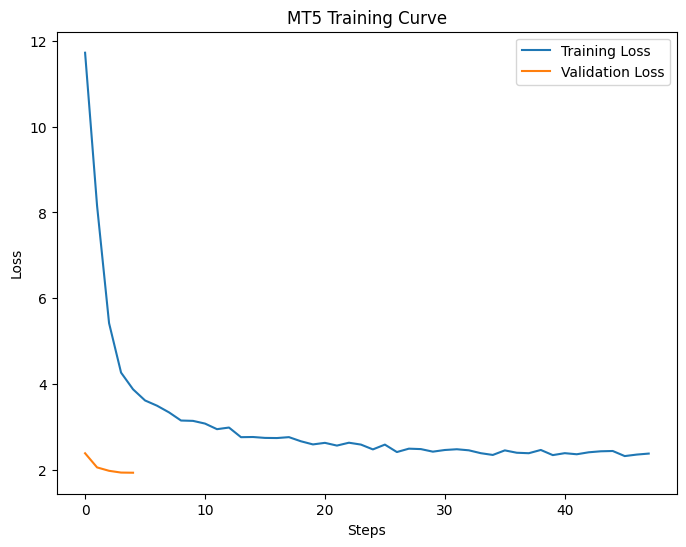

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

if "loss" in log_df.columns:
    plt.plot(
        log_df["loss"].dropna().values,
        label="Training Loss"
    )

if "eval_loss" in log_df.columns:
    plt.plot(
        log_df["eval_loss"].dropna().values,
        label="Validation Loss"
    )

plt.legend()
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("MT5 Training Curve")

plt.savefig("/content/training_curve.png")
plt.show()

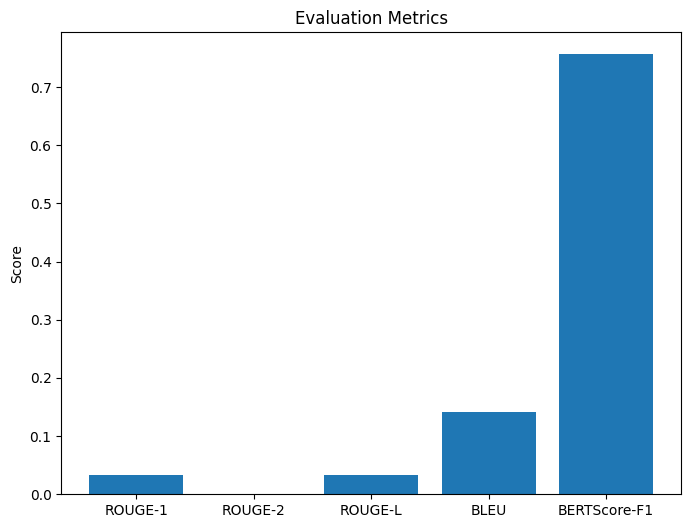

In [ ]:
plt.figure(figsize=(8,6))

plt.bar(
    metrics_df["Metric"],
    metrics_df["Score"]
)

plt.title("Evaluation Metrics")
plt.ylabel("Score")

plt.savefig("/content/metrics_plot.png")
plt.show()

In [ ]:
sample_df = pred_df.head(20)

sample_df.to_csv(
    "/content/sample_outputs.csv",
    index=False
)

In [ ]:
os.makedirs("/content/final_results", exist_ok=True)

shutil.copy("/content/final_mt5_model.zip", "/content/final_results")
shutil.copy("/content/mt5_predictions.csv", "/content/final_results")
shutil.copy("/content/mt5_metrics.csv", "/content/final_results")
shutil.copy("/content/training_curve.png", "/content/final_results")
shutil.copy("/content/metrics_plot.png", "/content/final_results")
shutil.copy("/content/sample_outputs.csv", "/content/final_results")

'/content/final_results/sample_outputs.csv'

In [ ]:
shutil.make_archive(
    "/content/mt5_complete_results",
    "zip",
    "/content/final_results"
)

'/content/mt5_complete_results.zip'

In [ ]:
from google.colab import files

files.download("/content/final_mt5_model.zip")
files.download("/content/mt5_complete_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!ls -lh /content/final_mt5_model


total 2.2G
-rw-r--r-- 1 root root  828 May 13 13:18 config.json
-rw-r--r-- 1 root root  142 May 13 13:18 generation_config.json
-rw-r--r-- 1 root root 2.2G May 13 13:19 model.safetensors
-rw-r--r-- 1 root root  416 May 13 13:20 special_tokens_map.json
-rw-r--r-- 1 root root 4.2M May 13 13:20 spiece.model
-rw-r--r-- 1 root root  862 May 13 13:20 tokenizer_config.json
-rw-r--r-- 1 root root 5.8K May 13 13:20 training_args.bin


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

# LOAD SAVED MODEL
MODEL_PATH = "/content/final_mt5_model"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# TAKE SAMPLE FROM TEST SET
sample_article = test_df.iloc[0]["article"]
actual_summary = test_df.iloc[0]["summary"]

print("ARTICLE:\n")
print(sample_article[:2000])

print("\n" + "="*80)
print("ACTUAL SUMMARY:\n")
print(actual_summary)

# GENERATE SUMMARY
inputs = tokenizer(
    sample_article,
    return_tensors="pt",
    truncation=True,
    max_length=512
).to(device)

with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_length=128,
        min_length=20,
        num_beams=4,
        early_stopping=True,
        no_repeat_ngram_size=3
    )

pred_summary = tokenizer.decode(output_ids[0], skip_special_tokens=True)

print("\n" + "="*80)
print("PREDICTED SUMMARY:\n")
print(pred_summary)

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


ARTICLE:

ദില്ലി: ആള്ക്കൂട്ട കൊലപാതകത്തില് നിയമം ശക്തമാക്കുമെന്ന് വ്യക്തമാക്കി ആഭ്യന്തര മന്ത്രി അമിത് ഷാ.

ACTUAL SUMMARY:

ആള്ക്കൂട്ട കൊല: നിയമം ഭേദഗതി ചെയ്യുമെന്ന് അമിത് ഷാ, കമ്മിറ്റിയുടെ നിര്ദേശം നിര്ണായകം

PREDICTED SUMMARY:

അള്ക്കൂട്ട കൊലപാതകത്തില് നിയമ ശക്തമാക്കുമെന്ന് അമിത് ഷാ; നിയമ നടപടി ശക്തമാക്കും


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
import pandas as pd

# LOAD MODEL
MODEL_PATH = "/content/final_mt5_model"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# RANDOM 10 TEST SAMPLES
samples = test_df.sample(10, random_state=42).reset_index(drop=True)

results = []

for i in range(len(samples)):
    article = samples.loc[i, "article"]
    reference = samples.loc[i, "summary"]

    inputs = tokenizer(
        article,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_length=128,
            min_length=20,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3
        )

    prediction = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    results.append({
        "Sample": i + 1,
        "Reference Summary": reference,
        "Predicted Summary": prediction
    })

# DISPLAY
results_df = pd.DataFrame(results)

for _, row in results_df.iterrows():
    print("="*120)
    print(f"SAMPLE {row['Sample']}")
    print("\nREFERENCE SUMMARY:\n")
    print(row["Reference Summary"])
    print("\nPREDICTED SUMMARY:\n")
    print(row["Predicted Summary"])
    print("\n")

# OPTIONAL SAVE
results_df.to_csv("/content/sample_10_predictions.csv", index=False)
print("Saved: /content/sample_10_predictions.csv")

SAMPLE 1

REFERENCE SUMMARY:

അയോധ്യയ്ക്ക് 500 കോടി അനുവദിച്ച് യോഗി സര്ക്കാര്; വിമാനത്താവളം വരുന്നു

PREDICTED SUMMARY:

അയോധ്യയെ ജനശ്രദ്ധയാകര്ഷിക്കുന്ന നഗരമാക്കി മാറ്റാന് ബിജെപി സര്ക്കാര് ശ്രമം തുടങ്ങി


SAMPLE 2

REFERENCE SUMMARY:

റെക്കോഡ് കച്ചവടം ; മാന്ദ്യത്തെ മറികടന്ന് റോൾസ് റോയിസ്

PREDICTED SUMMARY:

ഉല്പ്പാദനം വെട്ടിച്ചുരുക്കിയും ജീവനക്കാരെ പിരിച്ചുവിട്ടും പ്ലാന്റുകള് പൂട്ടിയിട്ടുമൊക്കെ പിടിച്ചു നില്ക്കാന് പെടാപ്പാടുപെട്ട ഒരു വർഷം


SAMPLE 3

REFERENCE SUMMARY:

സ്വദേശി പ്രസ്ഥാനം ദേശീയവിദ്യാഭ്യാസത്തിന്റെ വളർച്ചയ്ക്കായി നിരവധി വിദ്യാലയങ്ങൾ സ്ഥാപിച്ചു. സ്ത്രീകളുടെ ഉന്നമനത്തിന് വിദ്യാഭ്യാസം അനിവാര്യമായിരുന്നു. 1916 ൽ ഡി.കെ. കാർവെ മഹാരാഷ്ട്രയിൽ ഇന്ത്യയിലെ ആദ്യത്തെ വനിതാ സർവകലാശാല സ്ഥാപിച്ചു.

PREDICTED SUMMARY:

ഇന്ത്യയിലെ ആദ്യത്തെ വനിതാ സർവകലാശാല സ്ഥാപിച്ചു. പാശ്ചാത്യ വിദ്യാഭ്യാസത്തോടും സാമൂഹിക അനാചാരങ്ങളോടുമുള്ള എതിർപ്പും ദേശീയമായ കാഴ്ചപ്പാടും ഇവയുടെ മുഖമുദ്രയായിരുന്നു.


SAMPLE 4

REFERENCE SUMMARY:

മറയൂരിൽ കുത്തിതുറന്നുള്ള കവർച്ചകൾ വ്യാപകം

PREDICTED SUMMARY:

ആരാധനാലയങ്ങളും 

In [ ]:
!ls -lh /content/final_mt5_model

total 2.2G
-rw-r--r-- 1 root root  828 May 13 13:18 config.json
-rw-r--r-- 1 root root  142 May 13 13:18 generation_config.json
-rw-r--r-- 1 root root 2.2G May 13 13:19 model.safetensors
-rw-r--r-- 1 root root  416 May 13 13:20 special_tokens_map.json
-rw-r--r-- 1 root root 4.2M May 13 13:20 spiece.model
-rw-r--r-- 1 root root  862 May 13 13:20 tokenizer_config.json
-rw-r--r-- 1 root root 5.8K May 13 13:20 training_args.bin


In [ ]:
!ls -lh /content | grep final_mt5

drwxr-xr-x 2 root root 4.0K May 13 13:20 final_mt5_model
-rw-r--r-- 1 root root 1.7G May 13 13:24 final_mt5_model.zip
